<a href="https://colab.research.google.com/github/mbrow210/MAT-422/blob/main/MAT422_Section_2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.3: Joint Distributions, Dependence, and Sampling

**Topics:** joint probability distributions, correlation and dependence, random samples

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(422)

## 2.3.1 Joint Probability Distributions

*A joint distribution gives the probability of every combination of values of two random variables. From the joint table we can get the marginal distributions, the conditional distributions, and check whether X and Y are independent.*

---


### Explanation

A joint probability distribution describes two random variables, $X$ and $Y$, at the same time by giving the probability $P(X=x, Y=y)$ for every pair of values. All of the probabilities in the table have to add up to 1.

> Marginal distribution
> - Found by summing the joint table over the other variable.
> - $P(X=x)=\sum_y P(x,y)$ (add across a row) and $P(Y=y)=\sum_x P(x,y)$ (add down a column)
> - Purpose: Shows how one variable behaves on its own.

> Conditional distribution
> - $P(Y=y \mid X=x)=\frac{P(x,y)}{P(X=x)}$
> - Purpose: Shows how $Y$ behaves once we already know $X$.

> Independence
> - $X$ and $Y$ are independent if $P(x,y)=P(x)P(y)$ for **every** cell in the table.
> - Purpose: Means knowing $X$ tells us nothing about $Y$.

TLDR: The joint table holds all the information. Marginals and conditionals are just different ways of slicing it.

### Working with a joint table by hand
1. Check that the table adds up to 1
2. Sum each row to get $P(X)$ and each column to get $P(Y)$
3. Divide a cell by its marginal to get a conditional probability
4. Compute $E[X]$, $E[Y]$, and $E[XY]$, then $Cov(X,Y)=E[XY]-E[X]E[Y]$
5. Compare the joint table to $P(X)P(Y)$ to test independence

In [ ]:
joint = np.array([[0.10, 0.20, 0.10],
                  [0.05, 0.25, 0.30]])
x_values = np.array([0, 1])
y_values = np.array([0, 1, 2])

px = joint.sum(axis=1)
py = joint.sum(axis=0)
print("Joint total =", joint.sum())
print("P(X) =", px)
print("P(Y) =", py)
print("P(Y=2 | X=1) =", joint[1, 2] / px[1])

Joint total = 1.0
P(X) = [0.4 0.6]
P(Y) = [0.15 0.45 0.4 ]
P(Y=2 | X=1) = 0.5


The joint table adds up to 1, so it is a valid distribution. The marginals show that $X=1$ is a bit more likely than $X=0$ (0.6 vs 0.4), and $Y=1$ and $Y=2$ are much more likely than $Y=0$. Given that $X=1$, the chance that $Y=2$ is 0.5.

In [ ]:
# Extension: the full conditional distribution of Y for each value of X
cond_y_given_x = joint / px[:, None]
print("P(Y | X=x), one row per value of X:")
print(cond_y_given_x)

# Extension: expectations and covariance
EX = (x_values * px).sum()
EY = (y_values * py).sum()
EXY = (np.outer(x_values, y_values) * joint).sum()
print(f"\nE[X] = {EX:.4f}, E[Y] = {EY:.4f}, E[XY] = {EXY:.4f}")
print("Cov(X, Y) =", EXY - EX * EY)

# Extension: independence check, does joint equal P(X)P(Y)?
product_of_marginals = np.outer(px, py)
print("\nP(X)P(Y) =")
print(product_of_marginals)
print("Largest difference from the joint table =", np.abs(joint - product_of_marginals).max())
print("Independent?", np.allclose(joint, product_of_marginals))

# Extension: my own table, independent by construction (outer product of two marginals)
joint_indep = np.outer([0.4, 0.6], [0.2, 0.5, 0.3])
print("\nMy independent table =")
print(joint_indep)
print("Independent?", np.allclose(joint_indep, np.outer(joint_indep.sum(axis=1), joint_indep.sum(axis=0))))

P(Y | X=x), one row per value of X:
[[0.25   0.5    0.25  ]
 [0.0833 0.4167 0.5   ]]

E[X] = 0.6000, E[Y] = 1.2500, E[XY] = 0.8500
Cov(X, Y) = 0.09999999999999998

P(X)P(Y) =
[[0.06 0.18 0.16]
 [0.09 0.27 0.24]]
Largest difference from the joint table = 0.060000000000000026
Independent? False

My independent table =
[[0.08 0.2  0.12]
 [0.12 0.3  0.18]]
Independent? True


The conditional rows are different from each other. Given $X=0$, $Y=2$ has probability 0.25, but given $X=1$ it is 0.5. If $X$ and $Y$ were independent, both rows would be the same as $P(Y)$. The covariance is positive (0.1), so larger values of $X$ tend to go with larger values of $Y$. The joint table also does not match $P(X)P(Y)$ in any cell, so the original variables are **not independent**.

The second table I built is different. Since it is made from an outer product, it passes the independence check.

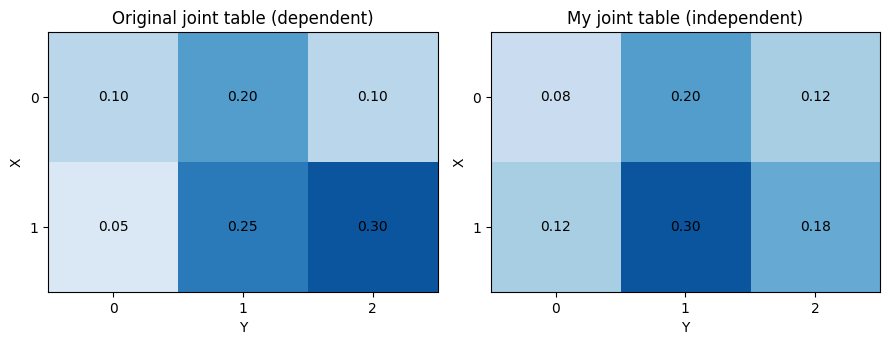

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
tables = [joint, joint_indep]
titles = ["Original joint table (dependent)", "My joint table (independent)"]

for ax, tbl, title in zip(axes, tables, titles):
    ax.imshow(tbl, cmap="Blues", vmin=0, vmax=0.35)
    ax.set_xticks(range(3))
    ax.set_yticks(range(2))
    ax.set_xlabel("Y")
    ax.set_ylabel("X")
    ax.set_title(title)
    for i in range(2):
        for j in range(3):
            ax.text(j, i, f"{tbl[i, j]:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()

The heatmaps show the same information as the tables. In the original, most of the probability sits in the bottom row on the right side (large $X$ and large $Y$). In my independent table, every row has the same shape, just scaled up or down.

## 2.3.2 Correlation and Dependence

*Correlation measures how strongly two variables move together in a straight line. Dependence is the bigger idea: $X$ and $Y$ are dependent if knowing one changes what we expect from the other, even when the relationship is not a line.*

---


### Explanation

The Pearson correlation between $X$ and $Y$ is:

$$\rho = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}$$

> $\rho$ close to $1$ or $-1$
> - Points fall close to a straight line.
> - Purpose: Strong linear relationship (positive or negative).

> $\rho$ close to $0$
> - No clear linear pattern.
> - Purpose: Shows there is no *linear* relationship. It does not rule out other kinds.

Independent variables always have correlation $0$, but correlation $0$ does **not** mean the variables are independent, because correlation cannot see nonlinear relationships.

TLDR: Correlation is a summary of linear dependence, not a test for independence.

corr(x, dependent y) = 0.9712234243536809
corr(x, independent y) = 0.0033608087993971117


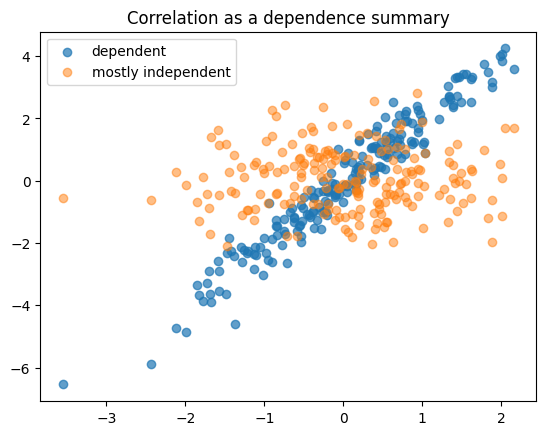

In [ ]:
x = rng.normal(0, 1, 200)
y_dependent = 2 * x + rng.normal(0, 0.5, 200)
y_independent = rng.normal(0, 1, 200)

print("corr(x, dependent y) =", np.corrcoef(x, y_dependent)[0, 1])
print("corr(x, independent y) =", np.corrcoef(x, y_independent)[0, 1])

plt.scatter(x, y_dependent, alpha=0.7, label="dependent")
plt.scatter(x, y_independent, alpha=0.5, label="mostly independent")
plt.legend()
plt.title("Correlation as a dependence summary")
plt.show()

The dependent $y$ (which is $2x$ plus a small amount of noise) has a correlation very close to 1, and the points form a tight line. The independent $y$ has a correlation very close to 0, but not exactly 0. That is because we only have 200 points, so there is always a little random fluctuation.

noise sd = 0.1: corr = 0.999
noise sd = 0.5: corr = 0.973
noise sd =   1: corr = 0.889
noise sd =   2: corr = 0.737
noise sd =   5: corr = 0.403


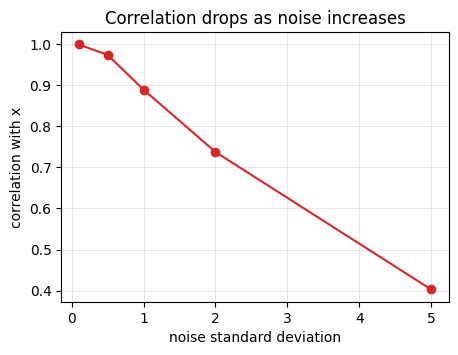

In [ ]:
# Extension: what happens to the correlation as the noise gets bigger? (y = 2x + noise)
noise_levels = [0.1, 0.5, 1, 2, 5]
corrs = []
for sigma in noise_levels:
    y = 2 * x + rng.normal(0, sigma, 200)
    corrs.append(np.corrcoef(x, y)[0, 1])
    print(f"noise sd = {sigma:>3}: corr = {corrs[-1]:.3f}")

plt.figure(figsize=(5, 3.5))
plt.plot(noise_levels, corrs, marker="o", color="tab:red")
plt.xlabel("noise standard deviation")
plt.ylabel("correlation with x")
plt.title("Correlation drops as noise increases")
plt.grid(True, alpha=0.3)
plt.show()

The relationship $y=2x$ never changes, but the correlation falls from about 0.999 with almost no noise to about 0.4 with a lot of noise. So correlation is measuring how tightly the points hug the line, not whether a relationship exists.

### Use case - Zero correlation is not independence

A good example of why correlation is only a summary is when $Y$ is completely determined by $X$ but not in a straight line. Here $Y=X^2$ is a perfect function of $X$, so knowing $X$ tells us everything about $Y$. But the relationship goes down on the left and up on the right, so the two sides cancel and the linear correlation ends up close to 0.

The example below also shows that using $|X|$ instead of $X$ fixes this, because the relationship becomes a steady increase that a straight line can pick up.

corr(x, x^2)         = -0.13038385793554785
corr(x, x^2 + noise) = -0.13122421585071298
corr(|x|, x^2)       = 0.9265062046102983


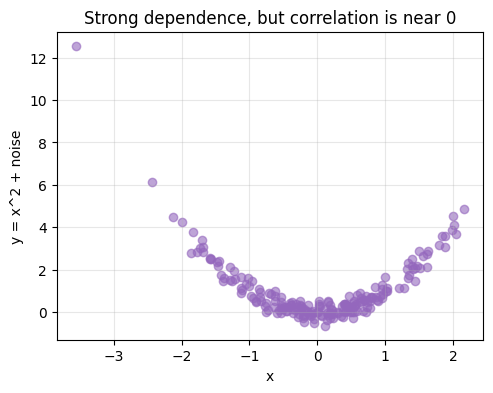

In [ ]:
y_quad = x ** 2
y_noisy_quad = x ** 2 + rng.normal(0, 0.3, 200)

print("corr(x, x^2)         =", np.corrcoef(x, y_quad)[0, 1])
print("corr(x, x^2 + noise) =", np.corrcoef(x, y_noisy_quad)[0, 1])
print("corr(|x|, x^2)       =", np.corrcoef(np.abs(x), y_quad)[0, 1])

plt.figure(figsize=(5.5, 4))
plt.scatter(x, y_noisy_quad, alpha=0.6, color="tab:purple")
plt.xlabel("x")
plt.ylabel("y = x^2 + noise")
plt.title("Strong dependence, but correlation is near 0")
plt.grid(True, alpha=0.3)
plt.show()

The plot shows a clear U shape, so $Y$ is obviously dependent on $X$, yet the correlation is only about $-0.13$. Once we use $|X|$, the correlation jumps to about 0.93. This is why a correlation near 0 should never be used by itself as proof that two variables are independent.

## 2.3.3 Random Samples

*A random sample is a set of independent draws from the same distribution. A statistic, like the sample mean, changes from sample to sample, and the distribution of that statistic is called its sampling distribution.*

---


### Explanation

Suppose the population has mean $\mu$ and standard deviation $\sigma$, and we take a random sample $X_1, \dots, X_n$ and compute the sample mean $\bar{X}$.

> Unbiased
> - $E[\bar{X}]=\mu$
> - Purpose: On average the sample mean lands on the true mean.

> Standard error
> - $SD(\bar{X})=\frac{\sigma}{\sqrt{n}}$
> - Purpose: Shows that a bigger sample gives a less spread out sample mean.

> Central Limit Theorem
> - For large $n$, $\bar{X}$ is approximately normal, even if the population is not.
> - Purpose: Lets us use the normal distribution to describe sample means.

TLDR: The center of the sample mean stays at $\mu$, the spread shrinks as $n$ grows, and the shape becomes bell shaped.

In the example below the population is exponential with scale 2, so $\mu=2$ and $\sigma=2$. It is strongly skewed to the right.

Mean of sample means = 2.002939496685325
Std of sample means = 0.3591243630203818


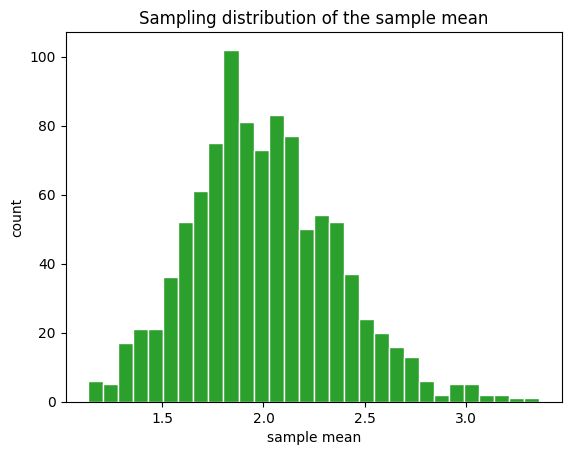

In [ ]:
sample_means = []
for _ in range(1000):
    sample = rng.exponential(scale=2.0, size=30)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)
print("Mean of sample means =", sample_means.mean())
print("Std of sample means =", sample_means.std())

plt.hist(sample_means, bins=30, color="tab:green", edgecolor="white")
plt.title("Sampling distribution of the sample mean")
plt.xlabel("sample mean")
plt.ylabel("count")
plt.show()

The mean of the sample means is very close to the true mean of 2, and the standard deviation is close to the theory value of $2/\sqrt{30} \approx 0.365$. Even though the population is skewed, the histogram of sample means looks mostly symmetric.

### Use case - Changing the sample size

The example below changes the sample size $n$ to 5, 30, and 200, and uses 5000 repetitions instead of 1000 to reduce the simulation noise. Each histogram has the normal curve from the Central Limit Theorem drawn on top, so we can see how good the approximation is for each $n$.

n =   5: mean of means = 1.9762 (theory 2.0), std of means = 0.8785 (theory 0.8944)
n =  30: mean of means = 1.9917 (theory 2.0), std of means = 0.3637 (theory 0.3651)
n = 200: mean of means = 2.0005 (theory 2.0), std of means = 0.1406 (theory 0.1414)


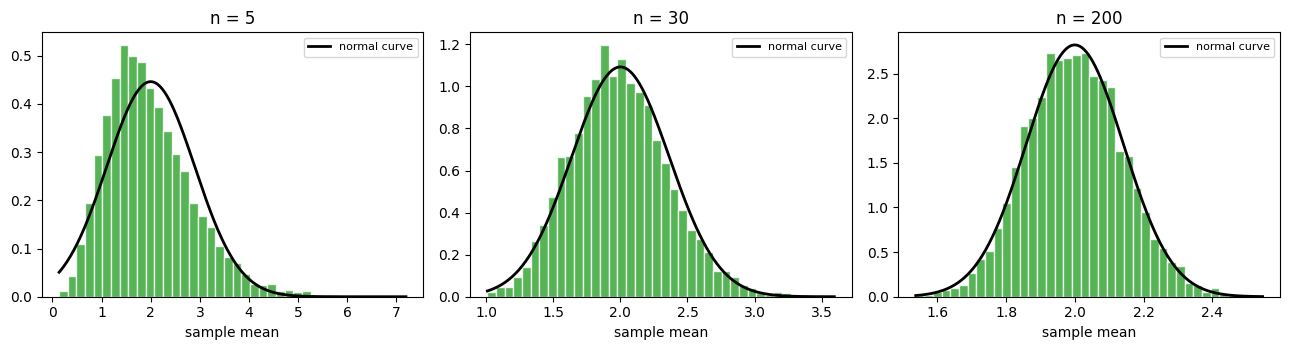

In [ ]:
from math import sqrt, pi

mu, sigma, reps = 2.0, 2.0, 5000
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

for ax, n in zip(axes, [5, 30, 200]):
    means = rng.exponential(scale=2.0, size=(reps, n)).mean(axis=1)
    se = sigma / sqrt(n)
    print(f"n = {n:>3}: mean of means = {means.mean():.4f} (theory {mu}), "
          f"std of means = {means.std():.4f} (theory {se:.4f})")

    ax.hist(means, bins=40, density=True, color="tab:green", edgecolor="white", alpha=0.8)
    grid = np.linspace(means.min(), means.max(), 300)
    normal_curve = np.exp(-(grid - mu) ** 2 / (2 * se ** 2)) / (se * sqrt(2 * pi))
    ax.plot(grid, normal_curve, "k-", linewidth=2, label="normal curve")
    ax.set_title(f"n = {n}")
    ax.set_xlabel("sample mean")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The center stays at 2 no matter what $n$ is, but the spread shrinks like $1/\sqrt{n}$. Going from $n=5$ to $n=200$ makes the standard error about 6 times smaller. At $n=5$ the histogram is still a little skewed to the right and does not match the normal curve perfectly, while at $n=200$ the fit is very close. The more skewed the population is, the larger $n$ has to be before the normal approximation works well.